<a href="https://colab.research.google.com/github/ankit-rathi/Quantvesting_v3/blob/main/notebooks/02_MY_PORTFOLIO_HEALTH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/ankit-rathi/Quantvesting_v3/blob/main/notebooks/02_MY_PORTFOLIO_HEALTH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Customer journey:** Understand portfolio value, allocation, concentration, P/L and FTT opportunity.


# Quantvesting

## Portfolio Analysis

Interactive portfolio analysis with compact summary and category distribution.

In [1]:
!pip install -q ta pyxirr matplotlib


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.4/532.4 kB 10.9 MB/s eta 0:00:00


In [2]:
# 1. Environment & imports

from google.colab import drive
drive.mount('/content/drive')

import sys

PROJECT = "/content/drive/My Drive/quantvesting_v3"
MARKET_DATA_DIR = PROJECT + "/market_data"
PORTFOLIO_ID = "vinod"  # change only this value for another user
PORTFOLIO_DATA_DIR = PROJECT + f"/portfolio_data/{PORTFOLIO_ID}"

# Phase A: set True only for the final EOD run.
EOD_RUN = False

sys.path.insert(0, PROJECT + "/src")

from quantvesting import (
    Quantvesting,
    load_config,
    load_market_data,
    load_portfolio_data,
    create_run_id,
    PROSPECT_DISPLAY_COLUMNS,
    PORTFOLIO_DISPLAY_COLUMNS,
)

RUN_ID = create_run_id()


Mounted at /content/drive


In [3]:
# 2. Load shared market data + this user's portfolio

config = load_config(
    PROJECT + "/config/strategy.yaml"
)

market_data = load_market_data(MARKET_DATA_DIR)
portfolio_data = load_portfolio_data(
    PORTFOLIO_DATA_DIR,
    portfolio_id=PORTFOLIO_ID,
)

qv = Quantvesting(config)


In [4]:
# 3. Run portfolio analysis
# EOD_RUN=False -> analysis only
# EOD_RUN=True  -> replace/create today's IST snapshot in myPortfolioDB.csv

df_portfolio, portfolio_summary = qv.portfolio(
    market_data,
    portfolio_data=portfolio_data,
    eod=EOD_RUN,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
)


In [5]:
# 4. Interactive portfolio view

qv.display_dataframe(
    df_portfolio,
    columns=PORTFOLIO_DISPLAY_COLUMNS,
    sort_by="FTT Amt",
    ascending=True,
)


,Symbol,Today P/L%,Current P/L%,FTT%,OTT%,FTT Amt,Current P/L,Current,FTT,Dev%_PE,RSI_14,Conviction,Spread%,CumlRnk,RRR Ind,CurrAlloc%,Gained%,Criteria,Strategy,Category
0,HDFCBANK,1.18,-56.67,50.07,-34.97,71600.0,-187000.0,143000.0,1073.00,-29.51,42.0,X-LC,12.90,26.0,-2.61,26.26,2.03,X40,BTT,BANKS
1,INFY,0.11,-21.97,74.28,36.00,126072.0,-47775.0,169725.0,1972.00,-40.86,50.0,X-LC,13.67,3.0,-0.38,31.16,14.84,X40,NTT,IT
2,TCS,-0.04,-27.52,82.42,32.21,191148.0,-88080.0,231920.0,4230.71,-43.64,50.0,X-LC,11.07,2.0,-0.46,42.58,17.62,X40,ATH,IT


In [6]:
# 5. Compact portfolio summary

qv.display_run_summary(portfolio_summary)


## Run date time (IST): 2026-09-04 12:36:58

Deployed:  8.68 L  
Current:  5.45 L  
CAGR/XIRR %: N/A

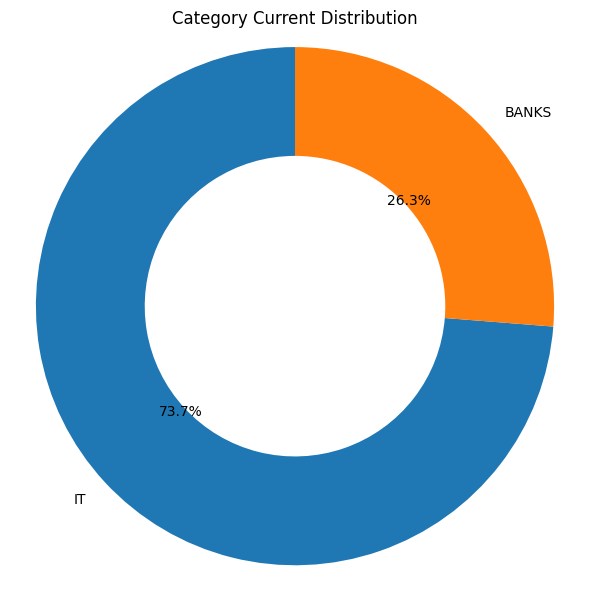

,Current
Category,
IT,401645.0
BANKS,143000.0


In [7]:
# 6. Current portfolio category distribution

qv.display_portfolio_category_chart(
    df_portfolio,
    category_column="Category",
    value_column="Current",
    title="Category Current Distribution",
)


### Optional decision layer

In [8]:
# 7. Portfolio actions

df_portfolio_actions = qv.portfolio_actions(df_portfolio)

qv.display_dataframe(
    df_portfolio_actions,
    columns=PORTFOLIO_DISPLAY_COLUMNS,
    sort_by="CurrAlloc%",
    ascending=False,
)


,Symbol,Today P/L%,Current P/L%,FTT%,OTT%,FTT Amt,Current P/L,Current,FTT,Dev%_PE,RSI_14,Conviction,Spread%,CumlRnk,RRR Ind,CurrAlloc%,Gained%,Criteria,Strategy,Category
2,TCS,-0.04,-27.52,82.42,32.21,191148.0,-88080.0,231920.0,4230.71,-43.64,50.0,X-LC,11.07,2.0,-0.46,42.58,17.62,X40,ATH,IT
1,INFY,0.11,-21.97,74.28,36.00,126072.0,-47775.0,169725.0,1972.00,-40.86,50.0,X-LC,13.67,3.0,-0.38,31.16,14.84,X40,NTT,IT
0,HDFCBANK,1.18,-56.67,50.07,-34.97,71600.0,-187000.0,143000.0,1073.00,-29.51,42.0,X-LC,12.90,26.0,-2.61,26.26,2.03,X40,BTT,BANKS
